## Universidad Nacional de Colombia
# Minería de Datos
**Prof. Elizabeth León**

# Proyecto

**Integrantes**

- Juan Felipe Bejarano Salazar
- Gian Emanuel Morales González
- David Felipe Marin Rosas
- Luis Esteban León Rojas

**Conjunto de Datos: Steam Games Datset**

Steam Games Datset - Información de los juegos de la plataforma Steam

*   Proviene de una fuente externa ( [games.csv](https://www.kaggle.com/datasets/fronkongames/steam-games-dataset)).

*   122611 observaciones, cada una representando un juego diferente.
*   El conjunto de datos cuenta con 39 variables:
    *   Algunas de las variables que incluye:
    *   `AppID`: Identificador único del juego en Steam. **Nominal (Identificador)**.
    *   `Name`: Nombre del juego. **Nominal**.
    *   `Release date`: Fecha de lanzamiento del juego. **Intervalo (Temporal)**.
    *   `Estimated owners`: Rango estimado de propietarios del juego. **Ordinal**.
    *   `Peak CCU`: Pico histórico de usuarios concurrentes. **Razón**.
    *   `Required age`: Edad mínima requerida para jugar. **Razón**.
    *   `Price`: Precio del juego en dólares estadounidenses. **Razón**.
    *   `Discount`: Porcentaje de descuento aplicado al juego. **Razón**.
    *   `DLC count`: Número de contenidos descargables asociados al juego. **Razón**.
    *   `Short description`: Descripción breve del juego. **Nominal (Texto)**.
    *   `About the game`: Descripción detallada del juego. **Nominal (Texto)**.
    *   `Reviews`: Texto de reseñas del juego. **Nominal (Texto)**.
    *   `Header image`: URL de la imagen principal en la tienda. **Nominal**.
    *   `Website`: Sitio web oficial del juego. **Nominal**.
    *   `Support url`: URL de soporte técnico. **Nominal**.
    *   `Support email`: Correo electrónico de soporte. **Nominal**.
    *   `Windows`: Indica si el juego es compatible con Windows. **Nominal binaria**.
    *   `Mac`: Indica si el juego es compatible con Mac. **Nominal binaria**.
    *   `Linux`: Indica si el juego es compatible con Linux. **Nominal binaria**.
    *   `Metacritic score`: Puntuación del juego en Metacritic. **Intervalo**.
    *   `Metacritic url`: URL de la página del juego en Metacritic. **Nominal**.
    *   `User score`: Puntuación promedio otorgada por los usuarios. **Intervalo**.
    *   `Positive`: Número de reseñas positivas. **Razón**.
    *   `Negative`: Número de reseñas negativas. **Razón**.
    *   `Score rank`: Clasificación relativa del juego según puntuación. **Ordinal**.
    *   `Achievements`: Número total de logros disponibles en el juego. **Razón**.
    *   `Recommendations`: Número de recomendaciones realizadas por usuarios. **Razón**.
    *   `Notes`: Notas adicionales sobre el juego. **Nominal (Texto)**.
    *   `Average playtime forever`: Tiempo promedio total de juego (en minutos). **Razón**.
    *   `Average playtime two weeks`: Tiempo promedio jugado en las últimas dos semanas (en minutos). **Razón**.
    *   `Median playtime forever`: Mediana del tiempo total jugado (en minutos). **Razón**.
    *   `Median playtime two weeks`: Mediana del tiempo jugado en las últimas dos semanas (en minutos). **Razón**.
    *   `Developers`: Desarrolladores del juego. **Nominal multivaluada**.
    *   `Publishers`: Publicadores del juego. **Nominal multivaluada**.
    *   `Categories`: Categorías a las que pertenece el juego. **Nominal multivaluada**.
    *   `Genres`: Géneros del juego. **Nominal multivaluada**.
    *   `Tags`: Etiquetas asociadas al juego (pueden incluir peso). **Nominal multivaluada ponderada**.
    *   `Supported languages`: Idiomas soportados por el juego. **Nominal multivaluada**.
    *   `Full audio languages`: Idiomas disponibles con doblaje completo. **Nominal multivaluada**.
    *   `Screenshots`: URLs de capturas de pantalla del juego. **Nominal multivaluada**.
    *   `Movies`: URLs de videos promocionales del juego. **Nominal multivaluada**.


##Objetivo Inicial
Analizar qué variables del conjunto de datos se encuentran asociadas con el éxito de un videojuego en términos de críticas y ventas, con el propósito de modelar y predecir dichas características a partir de sus atributos.

Verificar si el dataset se ha cargado, mirando la pestaña de **archivos**. Si no, cargar el archivo *iris.data*. Para ejecutarlo:

In [ ]:
# Python
import pandas as pd
import numpy as np
from scipy.stats import trim_mean
from numpy import mean, absolute

In [ ]:
# Python
column_names = ["appID","Name","Release date","Estimated owners","Peak CCU","Required age","Price","Discount",
                "DLC count","About the game","Supported languages","Full audio languages","Reviews",
                "Header image","Website","Support URL","Support email","Windows","Mac","Linux",
                "Metacritic score","Metacritic URL","User score","Positive","Negative","Score rank",
                "Achievements","Recommendations","Notes","Average playtime forever","Average playtime two weeks","Median playtime forever",
                "Median playtime two weeks","Developers","Publishers","Categories","Genres","Tags",
                "Screenshots","Movies"]
data = pd.read_csv("./games.csv", on_bad_lines="skip", skiprows=1, header=None, names=column_names)

Ver el conjunto de datos:

In [ ]:
#Python
print(data)

          appID                                   Name  Release date  \
0       2539430             Black Dragon Mage Playtest   Aug 1, 2023   
1        496350  Supipara - Chapter 1 Spring Has Come!  Jul 29, 2016   
2       1034400      Mystery Solitaire The Black Raven   May 6, 2019   
3       3292190            버튜버 파라노이아 - Vtuber Paranoia  Oct 31, 2024   
4       3631080                          Maze Quest VR  Apr 24, 2025   
...         ...                                    ...           ...   
122606  4152910                                   完美传奇   Jan 4, 2026   
122607  4042800         Poker Fate - ACG Texas Hold'em   Jan 3, 2026   
122608  3522550                        Adira Nusantara   Jan 3, 2026   
122609  3680350                     A Lenda de Niterói   Jan 4, 2026   
122610  4141790                          [BEAT:KEEPER]   Jan 5, 2026   

       Estimated owners  Peak CCU  Required age  Price  Discount  DLC count  \
0                 0 - 0         0             0   0.00  

Para recuperar el ”header”:

In [ ]:
#Python
data.head()

,appID,Name,Release date,Estimated owners,Peak CCU,Required age,Price,Discount,DLC count,About the game,...,Average playtime two weeks,Median playtime forever,Median playtime two weeks,Developers,Publishers,Categories,Genres,Tags,Screenshots,Movies
0,2539430,Black Dragon Mage Playtest,"Aug 1, 2023",0 - 0,0,0,0.00,0,0,NaN,...,0,0,0,NaN,NaN,NaN,NaN,NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
1,496350,Supipara - Chapter 1 Spring Has Come!,"Jul 29, 2016",0 - 20000,0,0,5.24,65,0,"Springtime, April: when the cherry trees come ...",...,0,8,0,minori,MangaGamer,"Single-player,Steam Trading Cards,Steam Cloud,...",Adventure,"Adventure,Visual Novel,Anime,Cute",https://shared.akamai.steamstatic.com/store_it...,NaN
2,1034400,Mystery Solitaire The Black Raven,"May 6, 2019",0 - 20000,0,0,4.99,0,0,"Immerse yourself in the most beloved, mystical...",...,0,0,0,Somer Games,8floor,"Single-player,Family Sharing",Casual,"Casual,Card Game,Solitaire,Puzzle,Hidden Objec...",https://shared.akamai.steamstatic.com/store_it...,NaN
3,3292190,버튜버 파라노이아 - Vtuber Paranoia,"Oct 31, 2024",0 - 20000,1,0,8.99,0,1,"synopsis 'Hello, I'm Hiyoro, a new YouTuber!' ...",...,0,0,0,유진게임즈,유진게임즈,"Single-player,Steam Achievements,Family Sharing","Casual,Indie,Simulation",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN
4,3631080,Maze Quest VR,"Apr 24, 2025",0 - 20000,0,0,4.99,0,0,Its not just a Maze; its a Quest! Enter the ca...,...,0,0,0,Reality Expanded LLC,Reality Expanded LLC,"Single-player,VR Only,Steam Leaderboards,Famil...","Action,Early Access",NaN,https://shared.akamai.steamstatic.com/store_it...,NaN


## **Frecuencias por variables de interés**

Análisis de frecuencias para las variables clave del conjunto de datos.

### Sistemas Operativos (Windows, Mac, Linux)

In [ ]:
#Python
data[['Windows', 'Mac', 'Linux']].value_counts()

Windows  Mac    Linux
True     False  False    96918
         True   True     11303
                False     9957
         False  True      4389
False    True   False       30
         False  True        12
         True   True         2
Name: count, dtype: int64

### Estimated Owners

In [ ]:
#Python
data.groupby('Estimated owners').size()

Estimated owners
0 - 0                    21641
0 - 20000                75404
100000 - 200000           3454
1000000 - 2000000          729
10000000 - 20000000         51
100000000 - 200000000        4
20000 - 50000            11396
200000 - 500000           2853
2000000 - 5000000          405
20000000 - 50000000         31
50000 - 100000            5355
500000 - 1000000          1154
5000000 - 10000000         125
50000000 - 100000000         9
dtype: int64

**Frecuencias porcentuales:**

### Sistemas Operativos

In [ ]:
#Python
fp_os = data[['Windows', 'Mac', 'Linux']].value_counts() / data.shape[0] * 100
print(fp_os)

Windows  Mac    Linux
True     False  False    79.045110
         True   True      9.218586
                False     8.120805
         False  True      3.579614
False    True   False     0.024468
         False  True      0.009787
         True   True      0.001631
Name: count, dtype: float64


### Estimated Owners

In [ ]:
#Python
fp_owners = data.groupby('Estimated owners').size() / data.shape[0] * 100
print(fp_owners)

Estimated owners
0 - 0                    17.650129
0 - 20000                61.498560
100000 - 200000           2.817039
1000000 - 2000000         0.594563
10000000 - 20000000       0.041595
100000000 - 200000000     0.003262
20000 - 50000             9.294435
200000 - 500000           2.326871
2000000 - 5000000         0.330313
20000000 - 50000000       0.025283
50000 - 100000            4.367471
500000 - 1000000          0.941188
5000000 - 10000000        0.101948
50000000 - 100000000      0.007340
dtype: float64


## **Medidas de centralidad:**

Resume los valores observados en un único valor asociado al valor localizado en el centro.

La **media** es la medida mas común de tendencia central para una variable numérica.
Si tenemos m observaciones se calcula como la media aritmética o promedio:

>$mean(x) = \overline{x} = \frac{1}{m}
\sum_{i=1}^{m}x_{i}$

Problema:  sensible a outliers o valores atıpicos.

### Promedio de variables relevantes

In [ ]:
#Python
variables_relevantes = ['Peak CCU', 'Required age', 'Price', 'Discount', 'DLC count', 'Metacritic score', 'User score', 'Positive', 'Negative', 'Achievements', 'Recommendations', 'Average playtime forever', 'Average playtime two weeks', 'Median playtime forever', 'Median playtime two weeks']
data[variables_relevantes].mean()

Peak CCU                        54.593324
Required age                     0.167611
Price                            4.765091
Discount                        18.353663
DLC count                        0.545856
Metacritic score                 2.564941
User score                       0.024549
Positive                      1044.986135
Negative                       169.197429
Achievements                    18.087015
Recommendations                961.824967
Average playtime forever       208.023220
Average playtime two weeks      13.789268
Median playtime forever        173.570528
Median playtime two weeks       14.722170
dtype: float64

### Media robusta (Trimmed Mean) de variables relevantes

Se descartan el 10% de los valores extremos en ambos lados para obtener una estimación robusta a outliers.


La **media robusta**, eliminar valores de fracciones extremas: **media truncada  (trimmed mean)**.

En *R* se pone un segundo parametro a la función mean llamado trim, que define la fraccion de elementos extremos a descartar.

**Ejemplo:** Descartamos el 10\% de los valores extremos en el ejemplo anterior:


In [ ]:
#Python
trimmed_means = {}
for var in variables_relevantes:
    trimmed_means[var] = trim_mean(data[var].dropna(), 0.10)
import pandas as pd
pd.Series(trimmed_means)

Peak CCU                       0.084648
Required age                   0.000000
Price                          3.097823
Discount                      12.822151
DLC count                      0.056173
Metacritic score               0.000000
User score                     0.000000
Positive                      25.761594
Negative                       6.736392
Achievements                   8.266044
Recommendations               15.504134
Average playtime forever      14.302093
Average playtime two weeks     0.000000
Median playtime forever       13.295629
Median playtime two weeks      0.000000
dtype: float64

### Mediana de variables relevantes

**Mediana**

La mediana representa de posicion central de la variable que separa la mitad inferior y la mitad superior de las observaciones.

El valor donde para una mitad todos los valores son mayores que este, y para la otra mitad todos son menores.

La mediana es más robusta que la media

In [ ]:
#Python
data[variables_relevantes].median()

Peak CCU                      0.00
Required age                  0.00
Price                         2.24
Discount                      0.00
DLC count                     0.00
Metacritic score              0.00
User score                    0.00
Positive                      5.00
Negative                      1.00
Achievements                  2.00
Recommendations               0.00
Average playtime forever      0.00
Average playtime two weeks    0.00
Median playtime forever       0.00
Median playtime two weeks     0.00
dtype: float64

### **Percentiles**


*   El k-esimo percentil de una variable numérica es un valor tal que el k\% de las observaciones se encuentran debajo del percentil y el (100 − k) \% se encuentran sobre este valor.

*   En estadística se usan los \textbf{cuantiles} que son equivalentes a los percentiles expresados en fracciones en vez de porcentajes.




*    Los **cuartiles** son tres percentiles específicos:

      * El primer cuartil Q1 (lower quartile) es el percentil con k = 25.
      * El segundo cuartil Q2 es con k = 50 equivale a la mediana.
      * El tercer cuartil Q3 (upper quartile) es con k = 75.

El mínimo, los tres cuartiles y el máximo:


In [ ]:
data[variables_relevantes].quantile([0.0, 0.25, 0.5, 0.75, 1.0]).T

,0.00,0.25,0.50,0.75,1.00
Peak CCU,0.0,0.00,0.00,0.00,1013936.00
Required age,0.0,0.00,0.00,0.00,21.00
Price,0.0,0.55,2.24,5.24,999.98
Discount,0.0,0.00,0.00,40.00,100.00
DLC count,0.0,0.00,0.00,0.00,3703.00
Metacritic score,0.0,0.00,0.00,0.00,97.00
User score,0.0,0.00,0.00,0.00,100.00
Positive,0.0,0.00,5.00,37.00,7642084.00
Negative,0.0,0.00,1.00,10.00,1173003.00
Achievements,0.0,0.00,2.00,19.00,9821.00


## **Medidas de dispersión**

**Rango:** Diferencia entre el valor máximo y mínimo


In [27]:
#Python
max(data['Required age']) - min(data['Required age'])

999.98


**Desviación estándar:**: es la raíz cuadrada de la ***varianza*** que mide las diferencias cuadráticas promedio de todas las observaciones con respecto a la ***media***
>$var(x) = \frac{1}{m-1} \sum_{i=1}^{m}(x_{i}- \overline{x})^2 $

>$sd(x) = \sqrt{var(x)} $

In [28]:
#Python
data['Required age'].var()

157.02671094419526

In [29]:
#Python
data['Required age'].std()

12.53102992352166

**Desviación media absoluta:** AAD es la Desviación Media Absoluta, es una medida de dispersión más robusta a *outliers* que la Desviación Estándar.

m(x) es una medida de tendencia central de x (puede ser la mediana).

> $AAD(x) = \frac{1}{m} \sum_{i=1}^{m}|(x_{i}- m(x)| $

**Ejercicio:** Programar una funcion que calcule la AAD:

In [30]:
#Python
import statistics
def aad(x):
   a = mean(absolute(x - statistics.median(x)))
   return a

In [31]:
#Python
aad(data['Required age'])

np.float64(4.080253810832633)

## **Estadísticas multivariadas**

Comparar como varía una variable con respecto a otra

**Covarianza:** Mide el grado de variación lineal conjunta de variables.

>$cov(x,y) = \frac{1}{m-1} \sum_{i=1}^{m}(x_{i}-\overline{x}) (y_{i}-\overline{y})$

Donde cov(x, x) = var (x), si las variables son independientes la covarianza es 0

In [ ]:
# Lenguaje R
%%R
cov(iris$Sepal.Length,iris$Sepal.Width)

[1] -0.03926846


In [ ]:
# Python
np.cov(data['Sepal.Length'], data['Sepal.Width'])

array([[ 0.68569351, -0.03926846],
       [-0.03926846,  0.18800403]])

El parámetro de ***cov*** puede ser una matriz o un data.frame de variables numéricas. Para calcular la **matriz de covarianzas**:

In [ ]:
# Lenguaje R
%%R
cov(iris[,1:4])

             Sepal.Length Sepal.Width Petal.Length Petal.Width
Sepal.Length   0.68569351 -0.03926846    1.2736823   0.5169038
Sepal.Width   -0.03926846  0.18800403   -0.3217128  -0.1179812
Petal.Length   1.27368233 -0.32171275    3.1131794   1.2963875
Petal.Width    0.51690380 -0.11798121    1.2963875   0.5824143


In [ ]:
# Python
df = data.drop(columns=['Species'])
df.cov()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Sepal.Length,0.685694,-0.039268,1.273682,0.516904
Sepal.Width,-0.039268,0.188004,-0.321713,-0.117981
Petal.Length,1.273682,-0.321713,3.113179,1.296387
Petal.Width,0.516904,-0.117981,1.296387,0.582414


La **correlacion lineal** o **coefiente de correlación de Pearson** es una medida de relación que no depende de la escala de cada variable. Se define como:

> $r(x,y) = \frac{cov(x,y)}{sd(x)sd(y)} $

*   Varía entre −1 a 1. Un valor cercano a 1 indica que mientras una variable crece la otra tambien lo hace en una proporción lineal.
*   Un valor cercano a -1 indica una relacion inversa (una crece la otra decrece).
*   Si la correlación es cercana a 0 hay independencia lineal. Sin embargo, no implica que no pueda haber una relacion no-lineal entre las variables.

In [ ]:
# Lenguaje R
%%R
cor(iris[,1:4])

             Sepal.Length Sepal.Width Petal.Length Petal.Width
Sepal.Length    1.0000000  -0.1093692    0.8717542   0.8179536
Sepal.Width    -0.1093692   1.0000000   -0.4205161  -0.3565441
Petal.Length    0.8717542  -0.4205161    1.0000000   0.9627571
Petal.Width     0.8179536  -0.3565441    0.9627571   1.0000000


In [ ]:
#Python
df.corr()

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width
Sepal.Length,1.000000,-0.109369,0.871754,0.817954
Sepal.Width,-0.109369,1.000000,-0.420516,-0.356544
Petal.Length,0.871754,-0.420516,1.000000,0.962757
Petal.Width,0.817954,-0.356544,0.962757,1.000000


Para desplegar el resumen de todas las medidas al mismo tiempo. Si un atributo es nominal solo se despliega en top el valor mas frecuente y en unique el número de valores unicos.


In [ ]:
data.describe(include='all')

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
count,150.000000,150.000000,150.000000,150.000000,150
unique,NaN,NaN,NaN,NaN,3
top,NaN,NaN,NaN,NaN,Iris-setosa
freq,NaN,NaN,NaN,NaN,50
mean,5.843333,3.054000,3.758667,1.198667,NaN
std,0.828066,0.433594,1.764420,0.763161,NaN
min,4.300000,2.000000,1.000000,0.100000,NaN
25%,5.100000,2.800000,1.600000,0.300000,NaN
50%,5.800000,3.000000,4.350000,1.300000,NaN
75%,6.400000,3.300000,5.100000,1.800000,NaN


**Tablas de Contingencia**: se usan para analizar variables categóricas. La tabla contiene las frecuencias marginales de todos los pares de valores entre dos variables categóricas.


In [ ]:
# Lenguaje R
%%R
origen<-c("Bogota","Cali", "Bogota","Cartagenta","Bogota","Cali")
colegio<-c("Privado","Privado","Publico","Privado","Publico","Publico")
table(origen, colegio)

            colegio
origen       Privado Publico
  Bogota           1       2
  Cali             1       1
  Cartagenta       1       0


In [ ]:
#Python
###########

## **Histogramas**

*   Gráfica de la distribucion de los valores de una variable.
*   Los valores se dividen en bins y se crea una gráfica de barra por cada bin.
*   La altura de cada barra indica el numero de elementos o frecuencia del bin.

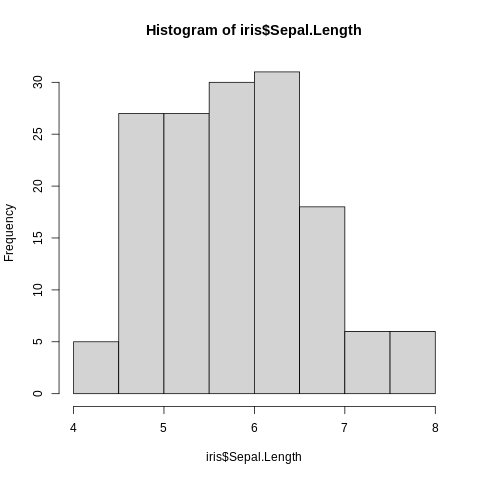

In [ ]:
# Lenguaje R
%%R
hist(iris$Sepal.Length)

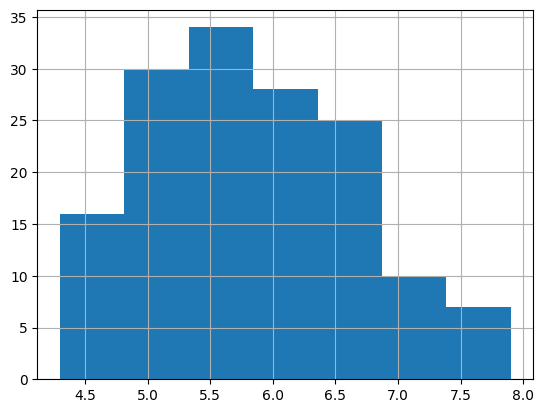

In [ ]:
#Python
hist = data['Sepal.Length'].hist(bins=7)

En R se puede definir el número de bins con `nclass`

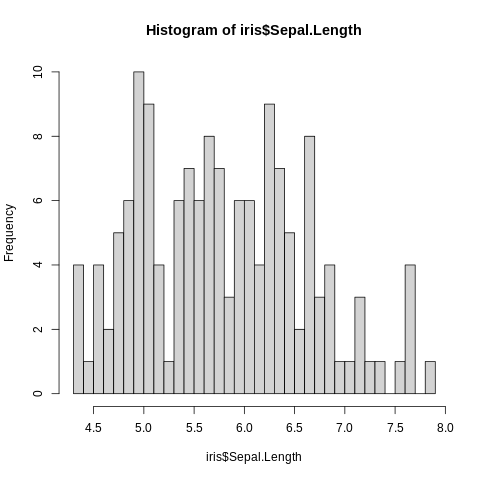

In [ ]:
# Lenguaje R
%%R
hist(iris$Sepal.Length, nclass=50)

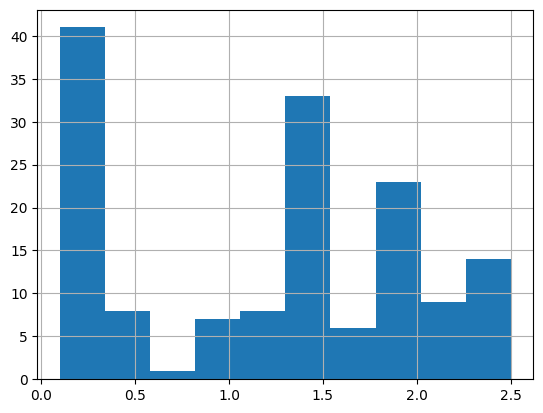

In [ ]:
#Python
hist = data['Petal.Width'].hist(bins=10)

## **Estimación de densidad**


*   Otra forma de visualizar los datos.
*   Se usan técnicas estadísticas no paramétricas: estimación de densidad de **kernel**.
*   Versión suavizada del histograma, permite determinar si los datos observados se comportan como una densidad conocida.

En R se crea con el comando `density`, y se visualiza con el comando `plot`

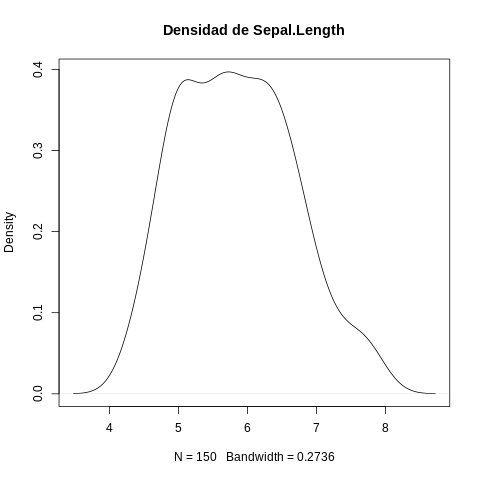

In [ ]:
# Lenguaje R
%%R
plot(density(iris$Sepal.Length),main="Densidad de Sepal.Length")

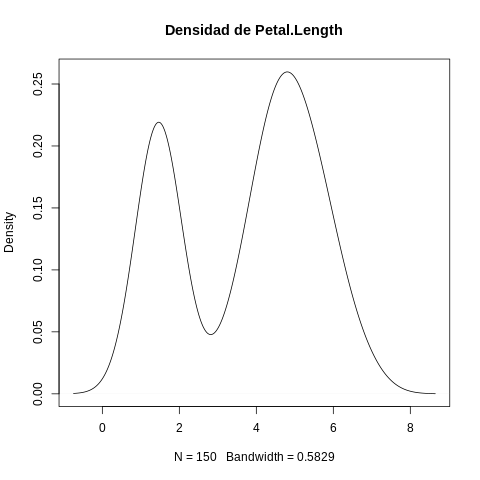

In [ ]:
%%R
plot(density(iris$Petal.Length),main="Densidad de Petal.Length")

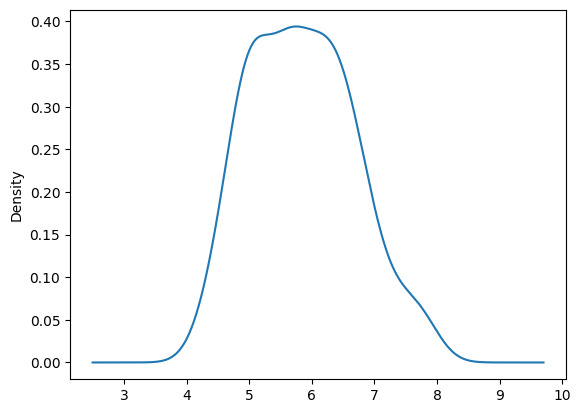

In [ ]:
#Python
ax = data['Sepal.Length'].plot.kde()

## **Diagramas de caja**

Se construyen a partir de los percentiles

En R se grafican con el comando `boxplot`

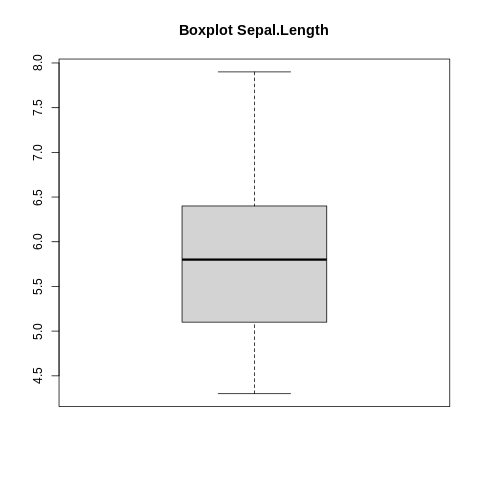

In [ ]:
# Lenguaje R
%%R
boxplot(iris$Sepal.Length,main="Boxplot Sepal.Length")

En R se pueden analizar varias variables al mismo tiempo:

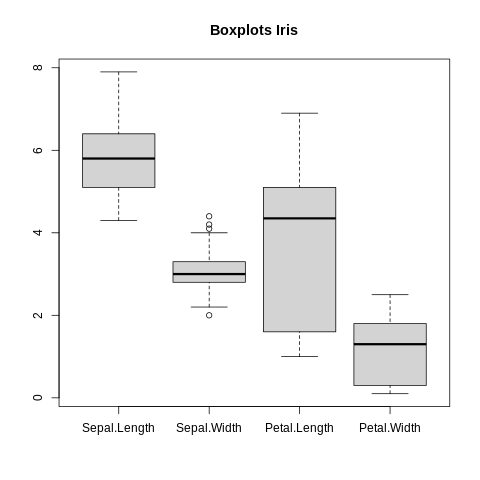

In [ ]:
# Lenguaje R
%%R
boxplot(x=iris[,1:4],main="Boxplots Iris")

<Axes: >

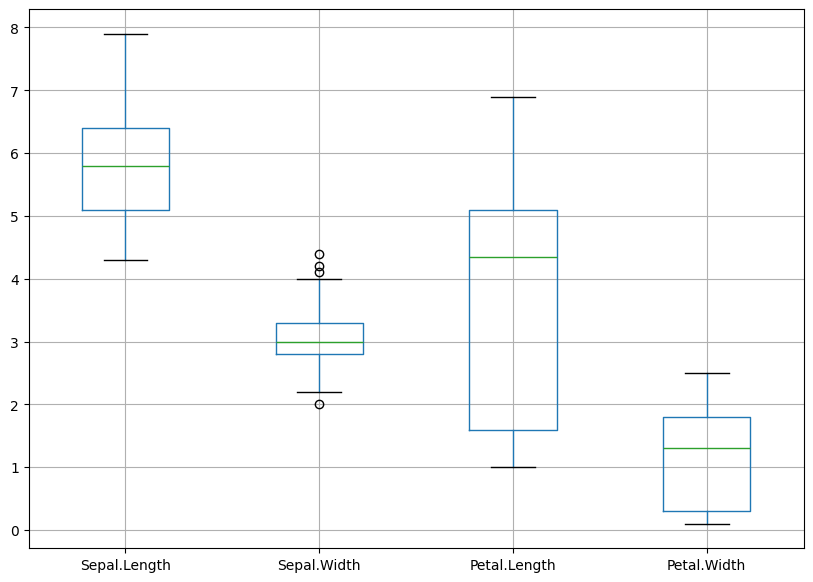

In [ ]:
#Python
import matplotlib.pyplot as plt
plt.figure(figsize = (10, 7))
data.boxplot()